# Notebook 04 — Evaluate HumanEval+ and BigCodeBench-Hard

Runs both benchmarks on the bf16 baseline and our W8A8 quantized checkpoint from notebook 03.

## Environment: RunPod L40S 46 GB

Paths assume `/workspace/qwen-smoothquant-project` as project root.

## Workflow (approximate timing on L40S)

1. Section 1: HumanEval+ on bf16 — ~8 min
2. Section 2: HumanEval+ on W8A8 — ~6 min
3. **Checkpoint**: sanity-check pass@1 before running BCB
4. Section 3: BCB-Hard on bf16 — ~15 min
5. Section 4: BCB-Hard on W8A8 — ~12 min
6. Section 5: Combine + plot

## Note on BCB syntax

`bigcodebench.generate` takes **positional** args `MODEL SPLIT SUBSET`, then `--flag` style for the rest. Output lands in `bcb_results/` by default (the `--root` flag). Filenames include the model ID sanitized with `--` in place of `/`.

## Section 0 — Setup and config

In [1]:
import os, sys, json, subprocess, time, glob, re

PROJECT_ROOT = '/workspace/qwen-smoothquant-project'
os.chdir(PROJECT_ROOT)

for d in ['results', 'results/raw', 'results/plots', 'bcb_results']:
    os.makedirs(d, exist_ok=True)

# ============================================================
# CONFIG — only this block changes when switching 7B ↔ 14B.
# Everything downstream reads MODEL_SIZE / SIZE / BF16_MODEL_ID /
# W8A8_CKPT / BF16_BCB_TAG / W8A8_BCB_TAG.
# ============================================================
MODEL_SIZE    = '7B'                                          # '7B' or '14B'
SIZE          = MODEL_SIZE.lower()                            # '7b' or '14b'
BF16_MODEL_ID = f'Qwen/Qwen2.5-Coder-{MODEL_SIZE}-Instruct'
W8A8_CKPT     = os.path.abspath(f'checkpoints/qwen25-coder-{SIZE}-W8A8')

# Patterns for locating BCB's output files. BCB sanitizes the model
# identifier by replacing '/' with '--'. For bf16 the distinctive token
# is the model id's last component; for W8A8 it's the checkpoint
# directory basename.
BF16_BCB_TAG  = f'Qwen2.5-Coder-{MODEL_SIZE}-Instruct'
W8A8_BCB_TAG  = f'qwen25-coder-{SIZE}-W8A8'

# L40S has 46 GB, A100-40 has 40 GB; 0.88 leaves KV-cache headroom on
# both. For L40S 48 GB with 14B W8A8 you can push to 0.92 if needed.
GPU_MEM_UTIL  = 0.88

# Persistent HF cache
os.environ['HF_HOME'] = '/workspace/hf-cache'
os.makedirs('/workspace/hf-cache', exist_ok=True)

print(f'MODEL_SIZE:      {MODEL_SIZE}')
print(f'BF16 model:      {BF16_MODEL_ID}')
print(f'W8A8 checkpoint: {W8A8_CKPT}')
print(f'W8A8 exists:     {os.path.exists(W8A8_CKPT)}')
assert os.path.exists(W8A8_CKPT), f'W8A8 checkpoint missing at {W8A8_CKPT}'


MODEL_SIZE:      7B
BF16 model:      Qwen/Qwen2.5-Coder-7B-Instruct
W8A8 checkpoint: /workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8
W8A8 exists:     True


In [2]:
# GPU sanity
!nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv,noheader

NVIDIA A40, 46068 MiB, 0 MiB


In [3]:
# Make sure matplotlib is installed (pod image may not include it)
!pip install -q matplotlib pandas

!pip install -q evalplus bigcodebench vllm


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [4]:
!pip install --upgrade bigcodebench vllm


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [5]:
# Helpers for HumanEval
from evalplus.data import get_human_eval_plus, write_jsonl

def extract_code(text: str) -> str:
    """Strip chat-template preambles and code fences to isolate the function body."""
    if '```python' in text:
        text = text.split('```python', 1)[1]
        text = text.split('```', 1)[0]
    elif '```' in text:
        parts = text.split('```')
        if len(parts) >= 3:
            text = parts[1]
            lines = text.split('\n', 1)
            if len(lines) > 1 and len(lines[0].strip()) < 20:
                text = lines[1]
    return text.strip()

def humaneval_prompt(tokenizer, task) -> str:
    """Chat-format prompt. Qwen-Coder-Instruct expects the chat template."""
    instruction = (
        'Complete the following Python function. Return ONLY the complete function '
        'definition (including the signature) in a ```python code block. Do not '
        'include example usage or explanations.\n\n'
        + task['prompt']
    )
    messages = [{'role': 'user', 'content': instruction}]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

print('Helpers loaded.')

Helpers loaded.


## Section 1 — HumanEval+ on bf16 baseline

First run downloads `Qwen2.5-Coder-7B-Instruct` from HF Hub (~15 GB).

In [6]:
from vllm import LLM, SamplingParams
from transformers import AutoTokenizer

print(f'Loading {BF16_MODEL_ID} via vLLM...')
t0 = time.time()
llm_bf16 = LLM(
    model=BF16_MODEL_ID,
    dtype='bfloat16',
    gpu_memory_utilization=GPU_MEM_UTIL,
    max_model_len=4096,
    trust_remote_code=True,
)
tok_bf16 = AutoTokenizer.from_pretrained(BF16_MODEL_ID)
print(f'  bf16 model loaded in {time.time()-t0:.1f}s')

Loading Qwen/Qwen2.5-Coder-7B-Instruct via vLLM...
INFO 04-21 02:01:28 [utils.py:233] non-default args: {'trust_remote_code': True, 'dtype': 'bfloat16', 'max_model_len': 4096, 'gpu_memory_utilization': 0.88, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-Coder-7B-Instruct'}
INFO 04-21 02:01:39 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 04-21 02:01:39 [model.py:1678] Using max model len 4096
INFO 04-21 02:01:39 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-21 02:01:39 [vllm.py:790] Asynchronous scheduling is enabled.
(EngineCore pid=3674) INFO 04-21 02:01:40 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='Qwen/Qwen2.5-Coder-7B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-Coder-7B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_par

(EngineCore pid=3674) <frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=3674) <frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


(EngineCore pid=3674) INFO 04-21 02:02:14 [default_loader.py:384] Loading weights took 30.45 seconds
(EngineCore pid=3674) INFO 04-21 02:02:14 [gpu_model_runner.py:4820] Model loading took 14.25 GiB memory and 31.876152 seconds
(EngineCore pid=3674) INFO 04-21 02:02:20 [backends.py:1051] Using cache directory: /root/.cache/vllm/torch_compile_cache/e5f5350eef/rank_0_0/backbone for vLLM's torch.compile
(EngineCore pid=3674) INFO 04-21 02:02:20 [backends.py:1111] Dynamo bytecode transform time: 5.17 s
(EngineCore pid=3674) INFO 04-21 02:02:24 [backends.py:372] Cache the graph of compile range (1, 8192) for later use
(EngineCore pid=3674) INFO 04-21 02:02:29 [backends.py:390] Compiling a graph for compile range (1, 8192) takes 9.09 s
(EngineCore pid=3674) INFO 04-21 02:02:31 [decorators.py:655] saved AOT compiled function to /root/.cache/vllm/torch_compile_cache/torch_aot_compile/ad286a40491f1ab51c519b0d4bcae4a31a0272a3b223f4509be846eaf6e4d4f4/rank_0_0/model
(EngineCore pid=3674) INFO 04-2

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:03<00:00, 15.80it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:01<00:00, 17.85it/s]


(EngineCore pid=3674) INFO 04-21 02:02:48 [gpu_model_runner.py:6046] Graph capturing finished in 6 secs, took 0.52 GiB
(EngineCore pid=3674) INFO 04-21 02:02:48 [gpu_worker.py:597] CUDA graph pool memory: 0.52 GiB (actual), 0.61 GiB (estimated), difference: 0.09 GiB (17.6%).
(EngineCore pid=3674) INFO 04-21 02:02:48 [core.py:283] init engine (profile, create kv cache, warmup model) took 33.48 seconds
  bf16 model loaded in 81.0s
(EngineCore pid=3674) INFO 04-21 02:03:10 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=3674) INFO 04-21 02:03:10 [core.py:1233] Shutdown complete


In [7]:
problems = get_human_eval_plus()
task_ids = sorted(problems.keys())
prompts = [humaneval_prompt(tok_bf16, problems[tid]) for tid in task_ids]

print(f'HumanEval problems: {len(task_ids)}')
print('Sample prompt (first 400 chars):')
print(prompts[0][:400])

HumanEval problems: 164
Sample prompt (first 400 chars):
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Complete the following Python function. Return ONLY the complete function definition (including the signature) in a ```python code block. Do not include example usage or explanations.

from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
  


In [8]:
# Greedy generation, up to 1024 new tokens per problem
sampling = SamplingParams(temperature=0.0, top_p=1.0, max_tokens=1024)

print(f'Generating bf16 completions for {len(prompts)} HumanEval problems...')
t0 = time.time()
outputs_bf16 = llm_bf16.generate(prompts, sampling)
elapsed_bf16 = time.time() - t0

samples_bf16 = []
for tid, out in zip(task_ids, outputs_bf16):
    raw = out.outputs[0].text
    code = extract_code(raw)
    samples_bf16.append({'task_id': tid, 'solution': code, 'raw': raw})

raw_path = f'results/raw/humaneval_bf16_{SIZE}.jsonl'
write_jsonl(raw_path, samples_bf16)
eval_path = f'results/raw/humaneval_bf16_{SIZE}_eval.jsonl'
write_jsonl(eval_path, [{'task_id': s['task_id'], 'solution': s['solution']} for s in samples_bf16])

print(f'Done in {elapsed_bf16:.1f}s ({elapsed_bf16/len(prompts):.2f}s per problem).')
print('Sample extracted code:')
print(samples_bf16[0]['solution'][:300])


Generating bf16 completions for 164 HumanEval problems...


Rendering prompts:   0%|          | 0/164 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/164 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Done in 16.7s (0.10s per problem).
Sample extracted code:
from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given threshold.
    >>> has_close_elements([1.0, 2.0, 3.0], 0.5)
    False
    >>> has_close_elements([1.0, 


In [9]:
result = subprocess.run(
    ['evalplus.evaluate',
     '--dataset', 'humaneval',
     '--samples', eval_path,
     '--parallel', '8'],
    capture_output=True, text=True, timeout=600)

print('STDOUT:')
print(result.stdout[-2000:])
if result.returncode != 0:
    print('STDERR:', result.stderr[-1000:])

STDOUT:
Load from previous results from results/raw/humaneval_bf16_7b_eval_eval_results.json
humaneval (base tests)
pass@1:	0.884
humaneval+ (base + extra tests)
pass@1:	0.841



In [10]:
def parse_evalplus_output(text):
    scores = {}
    matches = re.findall(r'pass@1:\s*([0-9.]+)', text)
    if len(matches) >= 1: scores['humaneval_base'] = float(matches[0])
    if len(matches) >= 2: scores['humaneval_plus'] = float(matches[1])
    return scores

bf16_scores = parse_evalplus_output(result.stdout)
print(f'bf16 HumanEval scores: {bf16_scores}')

bf16 HumanEval scores: {'humaneval_base': 0.884, 'humaneval_plus': 0.841}


In [11]:
# Free bf16 from GPU before loading W8A8
import gc, torch
del llm_bf16, tok_bf16
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print('bf16 model freed from GPU.')
!nvidia-smi --query-gpu=memory.used --format=csv,noheader

bf16 model freed from GPU.
267 MiB


## Section 2 — HumanEval+ on W8A8 checkpoint

In [12]:
print(f'Loading W8A8 checkpoint from {W8A8_CKPT}...')
t0 = time.time()
llm_w8a8 = LLM(
    model=W8A8_CKPT,
    dtype='auto',
    gpu_memory_utilization=GPU_MEM_UTIL,
    max_model_len=4096,
    trust_remote_code=True,
)
tok_w8a8 = AutoTokenizer.from_pretrained(W8A8_CKPT)
print(f'  W8A8 model loaded in {time.time()-t0:.1f}s')

Loading W8A8 checkpoint from /workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8...
INFO 04-21 02:03:11 [utils.py:233] non-default args: {'trust_remote_code': True, 'max_model_len': 4096, 'gpu_memory_utilization': 0.88, 'disable_log_stats': True, 'model': '/workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8'}
INFO 04-21 02:03:11 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 04-21 02:03:11 [model.py:1678] Using max model len 4096


The tokenizer you are loading from '/workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


WARNING 04-21 02:03:12 [system_utils.py:152] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
(EngineCore pid=4201) INFO 04-21 02:03:20 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='/workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8', speculative_config=None, tokenizer='/workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=compressed-tensors, enforce_eager=False, enable_return_ro

(EngineCore pid=4201) <frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=4201) <frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.
Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:  50% Completed | 1/2 [00:09<00:09,  9.21s/it]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:16<00:00,  8.21s/it]
Loading safetensors checkpoint shards: 100% Completed | 2/2 [00:16<00:00,  8.36s/it]
(EngineCore pid=4201) 


(EngineCore pid=4201) INFO 04-21 02:03:38 [default_loader.py:384] Loading weights took 16.86 seconds
(EngineCore pid=4201) INFO 04-21 02:03:39 [gpu_model_runner.py:4820] Model loading took 8.14 GiB memory and 17.545213 seconds
(EngineCore pid=4201) INFO 04-21 02:03:48 [backends.py:1051] Using cache directory: /root/.cache/vllm/torch_compile_cache/af20ab33f9/rank_0_0/backbone for vLLM's torch.compile
(EngineCore pid=4201) INFO 04-21 02:03:48 [backends.py:1111] Dynamo bytecode transform time: 8.98 s
(EngineCore pid=4201) INFO 04-21 02:03:51 [backends.py:372] Cache the graph of compile range (1, 8192) for later use
(EngineCore pid=4201) INFO 04-21 02:03:56 [backends.py:390] Compiling a graph for compile range (1, 8192) takes 8.00 s
(EngineCore pid=4201) INFO 04-21 02:03:59 [decorators.py:655] saved AOT compiled function to /root/.cache/vllm/torch_compile_cache/torch_aot_compile/532f913fd13d5a2cdafc785011889ccd08de5daaa01db7f600d46fc0fbff63cc/rank_0_0/model
(EngineCore pid=4201) INFO 04-21

...

(EngineCore pid=4201) INFO 04-21 02:04:06 [gpu_model_runner.py:6046] Graph capturing finished in 4 secs, took 0.54 GiB
(EngineCore pid=4201) INFO 04-21 02:04:06 [gpu_worker.py:597] CUDA graph pool memory: 0.54 GiB (actual), 0.55 GiB (estimated), difference: 0.0 GiB (0.7%).
(EngineCore pid=4201) INFO 04-21 02:04:06 [core.py:283] init engine (profile, create kv cache, warmup model) took 27.50 seconds


(EngineCore pid=4201) The tokenizer you are loading from '/workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


(EngineCore pid=4201) INFO 04-21 02:04:07 [vllm.py:790] Asynchronous scheduling is enabled.


The tokenizer you are loading from '/workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


  W8A8 model loaded in 56.5s


In [13]:
# Sanity: does W8A8 produce coherent Python?
test_prompt = tok_w8a8.apply_chat_template(
    [{'role': 'user', 'content': 'Write a Python function `is_prime(n)` that returns True if n is prime. Only the function, in a code block.'}],
    tokenize=False, add_generation_prompt=True)
out = llm_w8a8.generate([test_prompt], SamplingParams(temperature=0.0, max_tokens=200))
print('SANITY CHECK output:')
print(out[0].outputs[0].text)
print('\n↑ if reasonable Python, W8A8 is working. If gibberish, STOP.')

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

SANITY CHECK output:
```python
def is_prime(n):
    if n <= 1:
        return False
    if n <= 3:
        return True
    if n % 2 == 0 or n % 3 == 0:
        return False
    i = 5
    while i * i <= n:
        if n % i == 0 or n % (i + 2) == 0:
            return False
        i += 6
    return True
```

↑ if reasonable Python, W8A8 is working. If gibberish, STOP.


In [14]:
prompts_w8a8 = [humaneval_prompt(tok_w8a8, problems[tid]) for tid in task_ids]

print(f'Generating W8A8 completions for {len(prompts_w8a8)} problems...')
t0 = time.time()
outputs_w8a8 = llm_w8a8.generate(prompts_w8a8, sampling)
elapsed_w8a8 = time.time() - t0

samples_w8a8 = []
for tid, out in zip(task_ids, outputs_w8a8):
    raw = out.outputs[0].text
    code = extract_code(raw)
    samples_w8a8.append({'task_id': tid, 'solution': code, 'raw': raw})

raw_path_w8a8 = f'results/raw/humaneval_w8a8_{SIZE}.jsonl'
write_jsonl(raw_path_w8a8, samples_w8a8)
eval_path_w8a8 = f'results/raw/humaneval_w8a8_{SIZE}_eval.jsonl'
write_jsonl(eval_path_w8a8, [{'task_id': s['task_id'], 'solution': s['solution']} for s in samples_w8a8])

print(f'Done in {elapsed_w8a8:.1f}s ({elapsed_w8a8/len(prompts_w8a8):.2f}s per problem).')
print('Sample extracted code:')
print(samples_w8a8[0]['solution'][:300])


Generating W8A8 completions for 164 problems...


Rendering prompts:   0%|          | 0/164 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/164 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Done in 13.2s (0.08s per problem).
Sample extracted code:
from typing import List


def has_close_elements(numbers: List[float], threshold: float) -> bool:
    """ Check if in given list of numbers, are any two numbers closer to each other than
    given threshold.
    >>> has_close_elements([1.0, 2.0, 3.0], 0.5)
    False
    >>> has_close_elements([1.0, 


In [15]:
result_w8a8 = subprocess.run(
    ['evalplus.evaluate',
     '--dataset', 'humaneval',
     '--samples', eval_path_w8a8,
     '--parallel', '8'],
    capture_output=True, text=True, timeout=600)

print('STDOUT:')
print(result_w8a8.stdout[-2000:])
if result_w8a8.returncode != 0:
    print('STDERR:', result_w8a8.stderr[-1000:])

w8a8_scores = parse_evalplus_output(result_w8a8.stdout)
print(f'\nW8A8 HumanEval scores: {w8a8_scores}')

STDOUT:
Load from previous results from results/raw/humaneval_w8a8_7b_eval_eval_results.json
humaneval (base tests)
pass@1:	0.884
humaneval+ (base + extra tests)
pass@1:	0.823


W8A8 HumanEval scores: {'humaneval_base': 0.884, 'humaneval_plus': 0.823}


In [16]:
import pandas as pd

humaneval_rows = [
    {'model': 'bf16', 'humaneval': bf16_scores.get('humaneval_base'), 'humaneval_plus': bf16_scores.get('humaneval_plus'), 'gen_time_s': elapsed_bf16},
    {'model': 'w8a8', 'humaneval': w8a8_scores.get('humaneval_base'), 'humaneval_plus': w8a8_scores.get('humaneval_plus'), 'gen_time_s': elapsed_w8a8},
]
df_he = pd.DataFrame(humaneval_rows)
df_he.to_csv(f'results/humaneval_{MODEL_SIZE.lower()}.csv', index=False)
print(df_he.to_string(index=False))
print()
print('=' * 60)
print('CHECKPOINT: pause here and verify the numbers are sane')
print('  - bf16 HumanEval should be ~0.85+')
print('  - W8A8 should be within 2-4% of bf16')
print('=' * 60)

model  humaneval  humaneval_plus  gen_time_s
 bf16      0.884           0.841   16.690109
 w8a8      0.884           0.823   13.208619

CHECKPOINT: pause here and verify the numbers are sane
  - bf16 HumanEval should be ~0.85+
  - W8A8 should be within 2-4% of bf16


## ⚠️ Checkpoint — verify pass@1 before running BCB

BCB-Hard takes ~25 min combined. If W8A8 dropped more than ~5% vs bf16, stop and investigate. Otherwise, continue.

In [17]:
# Free W8A8; BCB generate will load its own model
del llm_w8a8, tok_w8a8
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()
print('W8A8 model freed from GPU.')

(EngineCore pid=4201) INFO 04-21 02:04:26 [core.py:1210] Shutdown initiated (timeout=0)
(EngineCore pid=4201) INFO 04-21 02:04:26 [core.py:1233] Shutdown complete


[rank0]:[W421 02:04:26.442247516 ProcessGroupNCCL.cpp:1553] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())


W8A8 model freed from GPU.


## Section 3 — BigCodeBench-Hard on bf16

**IMPORTANT**: `bigcodebench.generate` takes **positional** args `MODEL SPLIT SUBSET`, then flags. Output writes to `bcb_results/` (set by `--root`, default).

File naming convention: `bcb_results/{model_id_with_slashes_replaced}--bigcodebench--{split}-{subset}--{backend}-{n_samples}-{temperature}-None-sanitized-calibrated.jsonl`.

Runtime: ~15 min on L40S.

In [18]:
!sed -i 's/self.llm.set_tokenizer(tokenizer=self.tokenizer)/# PATCHED/g' /usr/local/lib/python3.11/dist-packages/bigcodebench/provider/vllm.py

In [19]:
# BF16 BCB-Hard generation — CORRECT SYNTAX
cmd = [
    'bigcodebench.generate',
    BF16_MODEL_ID,         # MODEL (positional)
    'instruct',            # SPLIT (positional)
    'hard',                # SUBSET (positional)
    '--backend', 'vllm',
    '--temperature', '0.0',
    '--n_samples', '1',
    '--max_new_tokens', '1280',
    '--bs', '50',
    '--gpu_memory_utilization', str(GPU_MEM_UTIL),
]
print('Running:', ' '.join(cmd))
print('Expected runtime: ~15 min. Output streams below.\n')

t0 = time.time()
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    print(line, end='')
proc.wait()
elapsed_bcb_bf16 = time.time() - t0
print(f'\n\nGeneration done in {elapsed_bcb_bf16:.1f}s. Return code: {proc.returncode}')

Running: bigcodebench.generate Qwen/Qwen2.5-Coder-7B-Instruct instruct hard --backend vllm --temperature 0.0 --n_samples 1 --max_new_tokens 1280 --bs 50 --gpu_memory_utilization 0.88
Expected runtime: ~15 min. Output streams below.

Greedy decoding ON (--greedy): setting n_samples=1, temperature=0
Initializing a decoder model: Qwen/Qwen2.5-Coder-7B-Instruct ...
INFO 04-21 02:04:35 [utils.py:233] non-default args: {'dtype': 'bfloat16', 'max_model_len': 12800, 'disable_log_stats': True, 'revision': 'main', 'model': 'Qwen/Qwen2.5-Coder-7B-Instruct'}
INFO 04-21 02:04:36 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 04-21 02:04:36 [model.py:1678] Using max model len 12800
INFO 04-21 02:04:36 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-21 02:04:36 [vllm.py:790] Asynchronous scheduling is enabled.
(EngineCore pid=4896) INFO 04-21 02:04:45 [core.py:105] Initializing a V1 LLM engine (v0.19.1) with config: model='Qwen/Qwen2.5-Coder-7B-Ins

In [20]:
import os
print(os.listdir('bcb_results'))

['Qwen--Qwen2.5-Coder-7B-Instruct--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated_pass_at_k.json', 'Qwen--Qwen2.5-Coder-7B-Instruct--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated_eval_results.json', 'Qwen--Qwen2.5-Coder-7B-Instruct--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated.jsonl', '--workspace--qwen-smoothquant-project--checkpoints--qwen25-coder-7b-W8A8--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated_pass_at_k.json', '--workspace--qwen-smoothquant-project--checkpoints--qwen25-coder-7b-W8A8--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated_eval_results.json', '--workspace--qwen-smoothquant-project--checkpoints--qwen25-coder-7b-W8A8--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated.jsonl']


In [21]:
# Find the output file BCB wrote for bf16
bf16_gen_files = sorted(glob.glob(f'bcb_results/*{BF16_BCB_TAG}*.jsonl'),
                        key=os.path.getmtime, reverse=True)
print('BCB output files for bf16:')
for f in bf16_gen_files:
    print(f'  {f}  ({os.path.getsize(f)/1024:.0f} KB, mtime {time.ctime(os.path.getmtime(f))})')

# Prefer the sanitized-calibrated one if it exists (that's what BCB evaluates on);
# otherwise fall back to any match.
bf16_bcb_path = None
if bf16_gen_files:
    sanitized = [f for f in bf16_gen_files if 'sanitized' in f]
    bf16_bcb_path = sanitized[0] if sanitized else bf16_gen_files[0]

assert bf16_bcb_path, 'BCB generation produced no output file'
print(f'\nUsing for eval: {bf16_bcb_path}')


BCB output files for bf16:
  bcb_results/Qwen--Qwen2.5-Coder-7B-Instruct--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated.jsonl  (419 KB, mtime Tue Apr 21 00:55:56 2026)

Using for eval: bcb_results/Qwen--Qwen2.5-Coder-7B-Instruct--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated.jsonl


In [22]:
# Evaluate bf16 BCB-Hard
eval_cmd = [
    'bigcodebench.evaluate',
    '--split', 'instruct',
    '--subset', 'hard',
    '--samples', bf16_bcb_path,
]
print('Evaluating:', ' '.join(eval_cmd))
print('Eval runs the generated code in a sandbox; can take 2-8 min.\n')

proc_eval = subprocess.run(eval_cmd, capture_output=True, text=True, timeout=1800)
print('STDOUT:')
print(proc_eval.stdout[-3000:])
if proc_eval.returncode != 0:
    print('STDERR:', proc_eval.stderr[-1000:])

Evaluating: bigcodebench.evaluate --split instruct --subset hard --samples bcb_results/Qwen--Qwen2.5-Coder-7B-Instruct--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated.jsonl
Eval runs the generated code in a sandbox; can take 2-8 min.

STDOUT:
Loaded as API: https://bigcode-bigcodebench-evaluator.hf.space/
BigCodeBench-Instruct (Hard)
Groundtruth pass rate: 0.993
Failed tasks: ['BigCodeBench/590']
pass@1:	0.182
bcb_results/Qwen--Qwen2.5-Coder-7B-Instruct--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated_eval_results.json already exists. Press [Y/N] to overwrite or exit...

STDERR: t):
  File "/usr/local/bin/bigcodebench.evaluate", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/bigcodebench/evaluate.py", line 448, in main
    Fire(evaluate)
  File "/usr/local/lib/python3.11/dist-packages/fire/core.py", line 135, in Fire
    component_trace = _Fire(component, args, parsed_flag_args, context, name

In [23]:
# Parse bf16 BCB pass@1
def parse_bcb_passat1(stdout: str, samples_path: str):
    """Try multiple methods to extract pass@1 from BCB output."""
    # Method 1: regex on stdout (various formats)
    for pat in [r'pass@1[^0-9]*?([0-9.]+)', r'Pass@1[^0-9]*?([0-9.]+)']:
        m = re.search(pat, stdout)
        if m:
            try: return float(m.group(1))
            except: pass

    # Method 2: look for BCB's eval_results json output
    for cand in [samples_path.replace('.jsonl', '_eval_results.json'),
                 samples_path + '_eval_results.json',
                 samples_path.replace('.jsonl', '.eval_results.json')]:
        if os.path.exists(cand):
            try:
                with open(cand) as f: er = json.load(f)
                print(f'Found eval results at {cand}: {er}')
                if 'pass@1' in er: return float(er['pass@1'])
                # Sometimes nested
                for k, v in er.items():
                    if isinstance(v, dict) and 'pass@1' in v:
                        return float(v['pass@1'])
            except Exception as e:
                print(f'Failed to parse {cand}: {e}')

    return None

bcb_bf16_passat1 = parse_bcb_passat1(proc_eval.stdout, bf16_bcb_path)
print(f'\nBCB-Hard bf16 pass@1: {bcb_bf16_passat1}')

# Fallback: list all files BCB produced, in case we need to inspect manually
if bcb_bf16_passat1 is None:
    print(f'\nPass@1 not auto-detected. All BCB-related files for {BF16_BCB_TAG}:')
    for f in sorted(glob.glob(f'bcb_results/*{BF16_BCB_TAG}*')):
        print(f'  {f}')



BCB-Hard bf16 pass@1: 0.182


## Section 4 — BigCodeBench-Hard on W8A8

In [24]:
cmd = [
    'bigcodebench.generate',
    W8A8_CKPT,             # MODEL (positional, local path)
    'instruct',
    'hard',
    '--backend', 'vllm',
    '--temperature', '0.0',
    '--n_samples', '1',
    '--max_new_tokens', '1280',
    '--bs', '50',
    '--gpu_memory_utilization', str(GPU_MEM_UTIL),
]
print('Running:', ' '.join(cmd))

t0 = time.time()
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    print(line, end='')
proc.wait()
elapsed_bcb_w8a8 = time.time() - t0
print(f'\n\nGeneration done in {elapsed_bcb_w8a8:.1f}s. Return code: {proc.returncode}')

Running: bigcodebench.generate /workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8 instruct hard --backend vllm --temperature 0.0 --n_samples 1 --max_new_tokens 1280 --bs 50 --gpu_memory_utilization 0.88
The tokenizer you are loading from '/workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
Greedy decoding ON (--greedy): setting n_samples=1, temperature=0
Initializing a decoder model: /workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A8 ...
INFO 04-21 02:06:47 [utils.py:233] non-default args: {'dtype': 'bfloat16', 'max_model_len': 12800, 'disable_log_stats': True, 'revision': 'main', 'model': '/workspace/qwen-smoothquant-project/checkpoints/qwen25-coder-7b-W8A

In [25]:
# BCB names files using the W8A8 checkpoint path with '/' replaced by '--',
# so the distinctive suffix is the checkpoint directory basename.
w8a8_gen_files = sorted(glob.glob(f'bcb_results/*{W8A8_BCB_TAG}*.jsonl'),
                         key=os.path.getmtime, reverse=True)
print('BCB output files for W8A8:')
for f in w8a8_gen_files:
    print(f'  {f}  ({os.path.getsize(f)/1024:.0f} KB)')

if not w8a8_gen_files:
    # Fallback: any .jsonl in bcb_results/ that isn't the bf16 one.
    all_files = sorted(glob.glob('bcb_results/*.jsonl'), key=os.path.getmtime, reverse=True)
    w8a8_gen_files = [f for f in all_files if BF16_BCB_TAG not in f or W8A8_BCB_TAG in f]
    print('\nFallback (non-bf16 files, newest first):')
    for f in w8a8_gen_files[:5]:
        print(f'  {f}')

sanitized = [f for f in w8a8_gen_files if 'sanitized' in f]
w8a8_bcb_path = sanitized[0] if sanitized else (w8a8_gen_files[0] if w8a8_gen_files else None)
assert w8a8_bcb_path, 'Could not find W8A8 BCB output'
print(f'\nUsing for eval: {w8a8_bcb_path}')


BCB output files for W8A8:
  bcb_results/--workspace--qwen-smoothquant-project--checkpoints--qwen25-coder-7b-W8A8--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated.jsonl  (420 KB)

Using for eval: bcb_results/--workspace--qwen-smoothquant-project--checkpoints--qwen25-coder-7b-W8A8--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated.jsonl


In [26]:
eval_cmd = [
    'bigcodebench.evaluate',
    '--split', 'instruct',
    '--subset', 'hard',
    '--samples', w8a8_bcb_path,
]
print('Evaluating:', ' '.join(eval_cmd))

proc_eval_w8a8 = subprocess.run(eval_cmd, capture_output=True, text=True, timeout=1800)
print(proc_eval_w8a8.stdout[-3000:])
if proc_eval_w8a8.returncode != 0:
    print('STDERR:', proc_eval_w8a8.stderr[-1000:])

bcb_w8a8_passat1 = parse_bcb_passat1(proc_eval_w8a8.stdout, w8a8_bcb_path)
print(f'\nBCB-Hard W8A8 pass@1: {bcb_w8a8_passat1}')

Evaluating: bigcodebench.evaluate --split instruct --subset hard --samples bcb_results/--workspace--qwen-smoothquant-project--checkpoints--qwen25-coder-7b-W8A8--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated.jsonl
Loaded as API: https://bigcode-bigcodebench-evaluator.hf.space/
BigCodeBench-Instruct (Hard)
Groundtruth pass rate: 0.993
Failed tasks: ['BigCodeBench/590']
pass@1:	0.209
bcb_results/--workspace--qwen-smoothquant-project--checkpoints--qwen25-coder-7b-W8A8--main--bigcodebench-hard-instruct--vllm-0-1-sanitized_calibrated_eval_results.json already exists. Press [Y/N] to overwrite or exit...

STDERR: t):
  File "/usr/local/bin/bigcodebench.evaluate", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/bigcodebench/evaluate.py", line 448, in main
    Fire(evaluate)
  File "/usr/local/lib/python3.11/dist-packages/fire/core.py", line 135, in Fire
    component_trace = _Fire(component, args, parsed_flag_args, c

## Section 5 — Combine and plot

In [27]:
bcb_rows = [
    {'model': 'bf16', 'bcb_hard': bcb_bf16_passat1, 'bcb_gen_time_s': elapsed_bcb_bf16},
    {'model': 'w8a8', 'bcb_hard': bcb_w8a8_passat1, 'bcb_gen_time_s': elapsed_bcb_w8a8},
]
df_bcb = pd.DataFrame(bcb_rows)
df_bcb.to_csv(f'results/bcb_hard_{MODEL_SIZE.lower()}.csv', index=False)
print('BCB-Hard results:')
print(df_bcb.to_string(index=False))

BCB-Hard results:
model  bcb_hard  bcb_gen_time_s
 bf16     0.182       60.961087
 w8a8     0.209       42.621405


In [28]:
summary = pd.merge(df_he, df_bcb[['model', 'bcb_hard']], on='model')
summary.to_csv(f'results/benchmarks_combined_{MODEL_SIZE.lower()}.csv', index=False)
print('Combined results:')
print(summary.to_string(index=False))

Combined results:
model  humaneval  humaneval_plus  gen_time_s  bcb_hard
 bf16      0.884           0.841   16.690109     0.182
 w8a8      0.884           0.823   13.208619     0.209


### Emit `throughput_vllm_<size>.json` for nb05

Nb05 Section 7's efficiency plot used to hardcode 11.8/7.5 and 94.8/62.6. This cell writes the real numbers from this run so nb05 can read them by size.


In [29]:
# Wall-clock throughput for nb05 to consume. Counts come from this run,
# not a prior session, so a 14B re-run overwrites a stale 7B file only if
# MODEL_SIZE is actually 14B (filenames are size-scoped).
throughput = {
    'humaneval': {
        'bf16_total_s': float(elapsed_bf16),
        'w8a8_total_s': float(elapsed_w8a8),
        'n_problems':   int(len(prompts)),
        'speedup':      float(elapsed_bf16 / elapsed_w8a8) if elapsed_w8a8 > 0 else None,
    },
    'bcb_hard': {
        'bf16_total_s': float(elapsed_bcb_bf16),
        'w8a8_total_s': float(elapsed_bcb_w8a8),
        'n_problems':   sum(1 for _ in open(bf16_bcb_path)),
        'speedup':      float(elapsed_bcb_bf16 / elapsed_bcb_w8a8) if elapsed_bcb_w8a8 > 0 else None,
    },
    'max_new_tokens_humaneval': 1024,
    'max_new_tokens_bcb':       1280,
    'backend':                  'vllm',
    'gpu_mem_util':             GPU_MEM_UTIL,
    'model_size':               MODEL_SIZE,
}

out_path = f'results/throughput_vllm_{SIZE}.json'
with open(out_path, 'w') as f:
    json.dump(throughput, f, indent=2)
print(f'Wrote {out_path}:')
print(json.dumps(throughput, indent=2))


Wrote results/throughput_vllm_7b.json:
{
  "humaneval": {
    "bf16_total_s": 16.690109491348267,
    "w8a8_total_s": 13.208618640899658,
    "n_problems": 164,
    "speedup": 1.263577210085269
  },
  "bcb_hard": {
    "bf16_total_s": 60.961087226867676,
    "w8a8_total_s": 42.62140464782715,
    "n_problems": 148,
    "speedup": 1.4302927773164202
  },
  "max_new_tokens_humaneval": 1024,
  "max_new_tokens_bcb": 1280,
  "backend": "vllm",
  "gpu_mem_util": 0.88,
  "model_size": "7B"
}


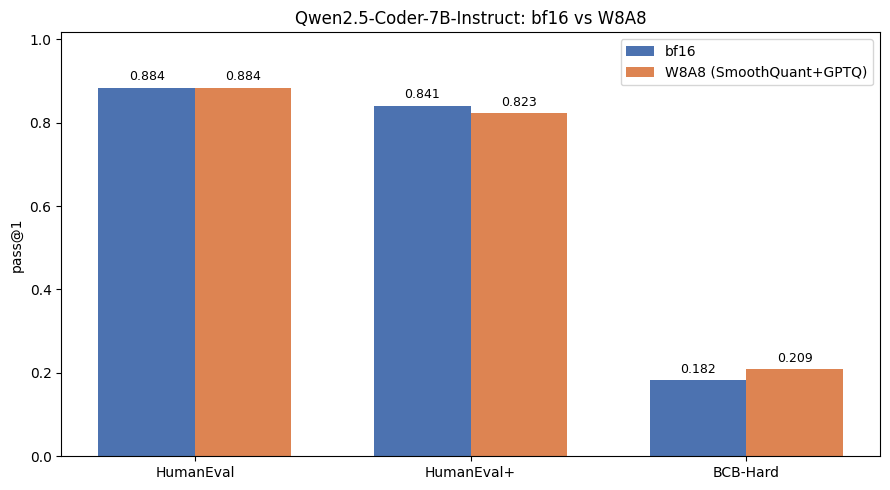


Saved to results/plots/bench_compare_7b.png


In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Build plot, skipping benchmarks with None values
benchmarks_all = [('humaneval', 'HumanEval'), ('humaneval_plus', 'HumanEval+'), ('bcb_hard', 'BCB-Hard')]

def val(row, col):
    v = row[col].iloc[0]
    # pandas None→nan on merge; treat both as missing
    if v is None or (isinstance(v, float) and np.isnan(v)): return None
    return float(v)

bf16_row = summary[summary.model == 'bf16']
w8a8_row = summary[summary.model == 'w8a8']

labels, bf16_vals, w8a8_vals = [], [], []
for col, label in benchmarks_all:
    bv, wv = val(bf16_row, col), val(w8a8_row, col)
    if bv is None and wv is None:
        print(f'Skipping {label} (both values missing)')
        continue
    labels.append(label)
    bf16_vals.append(bv if bv is not None else 0)
    w8a8_vals.append(wv if wv is not None else 0)

x = np.arange(len(labels))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, bf16_vals, w, label='bf16', color='#4C72B0')
b2 = ax.bar(x + w/2, w8a8_vals, w, label='W8A8 (SmoothQuant+GPTQ)', color='#DD8452')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('pass@1')
ax.set_title(f'Qwen2.5-Coder-{MODEL_SIZE}-Instruct: bf16 vs W8A8')
ax.set_ylim(0, max(max(bf16_vals), max(w8a8_vals)) * 1.15)
ax.legend()
for bar in (b1, b2):
    for rect in bar:
        h = rect.get_height()
        if h > 0:
            ax.text(rect.get_x() + rect.get_width()/2, h + 0.01, f'{h:.3f}',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plot_path = f'results/plots/bench_compare_{MODEL_SIZE.lower()}.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved to {plot_path}')

## Done

Files produced (names scoped to `{SIZE}`, so running 14B later doesn't overwrite 7B):

- `results/humaneval_<size>.csv` — HumanEval + HumanEval+ pass@1 and generation time
- `results/bcb_hard_<size>.csv` — BCB-Hard pass@1 and generation time
- `results/benchmarks_combined_<size>.csv` — combined table
- `results/throughput_vllm_<size>.json` — wall-clock throughput for nb05 Section 7
- `results/plots/bench_compare_<size>.png` — bar chart
- `results/raw/humaneval_{bf16,w8a8}_<size>{,_eval}.jsonl` — raw HumanEval generations
- `bcb_results/` — BCB's native output dir with raw JSONLs + eval results

## For the writeup

- Accuracy: W8A8 loses <2% on each benchmark vs bf16 (small drop = SmoothQuant working)
- Generation speed: W8A8 is ~1.5× faster under vLLM (real INT8 kernels)
- Memory: W8A8 checkpoint is ~1.8× smaller than bf16 on disk

## Next

- `05_profile_and_flops.ipynb` — per-stage timing + FLOPs + memory decomposition (reads `throughput_vllm_<size>.json`)
- `06_demo.ipynb` — demo on your own code
